# UMAP + DBSCAN Hyperparameter Tuning

## Objective

The purpose of this notebook is to find the best UMAP + DBSCAN clustering solution using the current cohort-scaled dataset.

The analysis follows the general approach :
- Use the Min-Max scaled clustering dataset
- Reduce the high-dimensional data to $2$ dimensions using UMAP
- Use Euclidean distance
- Tune important UMAP hyperparameters:
    - `n_neighbors`
    - `min_dist`
- For each UMAP embedding, estimate suitable DBSCAN `Epsilon` values using the k-distance knee method
- Apply DBSCAN using different `Epsilon` and `MinPts` values
- Evaluate every clustering solution using :
    - `Silhouette Score` : Higher is better
    - `Davies-Bouldin Index` : Lower is better
    - `Calinski-Harabasz Index` : Higher is better
- Examine the number of clusters
- Examine the number and percentage of outliers
- Compare clustering performance across different combinations of UMAP and DBSCAN hyperparameters
- Select the best practical clustering solution by considering internal validation metrics, cluster structure, cluster size, and the amount of noise

The number of clusters is not fixed in advance. It will be determined naturally by DBSCAN based on the density structure produced by the best-performing UMAP and DBSCAN hyperparameter combination.

## Import Required Libraries

This section imports the Python libraries needed for :
- Loading and working with the dataset
- Running UMAP
- Running DBSCAN
- Calculating clustering evaluation metrics
- Finding nearest-neighbor distances
- Detecting the knee point for DBSCAN epsilon selection
- Creating plots
- Saving the results

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from umap import UMAP
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

from kneed import KneeLocator

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

## Define Project Folder Paths

This section defines the locations of the data, results and plot folders for the UMAP + DBSCAN hyperparameter tuning analysis.

The results and plots folders will be created automatically if they do not already exist.

In [2]:
ROOT_DIR = Path.cwd().parent.parent

DATA_DIR = ROOT_DIR / "results" / "module_2" / "dataset_creation"
RESULTS_DIR = ROOT_DIR / "results" / "module_2" / "4.umap_dbscan_tuning"
PLOTS_DIR = ROOT_DIR / "plots" / "module_2" / "4.umap_dbscan_tuning"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("Root directory:", ROOT_DIR)
print("Data directory:", DATA_DIR)
print("Results directory:", RESULTS_DIR)
print("Plots directory:", PLOTS_DIR)

Root directory: C:\Users\samsa\Documents\ICU Clustering
Data directory: C:\Users\samsa\Documents\ICU Clustering\results\module_2\dataset_creation
Results directory: C:\Users\samsa\Documents\ICU Clustering\results\module_2\4.umap_dbscan_tuning
Plots directory: C:\Users\samsa\Documents\ICU Clustering\plots\module_2\4.umap_dbscan_tuning


## Load the Current Cohort-Scaled Dataset

The current cohort-scaled dataset is loaded in this section. The dataset should contain:
- One row for each patient
- One patient identifier column
- THe clustering features already transformed and Min-Max scaled

Because this dataset is already scaled, Min-Max scaling will not be repeated in this.

In [3]:
DATA_FILE = DATA_DIR / "clustering_dataset_scaled.csv"

df = pd.read_csv(DATA_FILE)

print(f"Shape of the dataset: {df.shape}")

Shape of the dataset: (7859, 81)


## Inspect the Dataset
Before running UMAP and DBSCAN, the dataset is checked to confirm:
- Number of patients
- Number of columns
- Column names
- Missing values
- Duplicate patients
- Whether the clustering features are within the expected Min-Max scaled range

In [4]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

print("\nColumn names:")
print(df.columns.tolist())

print("\nTotal missing values:")
print(df.isna().sum().sum())

# Patient identifier column
ID_COLUMN = "patientunitstayid"

print("\nUnique patients:")
print(df[ID_COLUMN].nunique())

print("\nDuplicate patient IDs:")
print(df[ID_COLUMN].duplicated().sum())

# Clustering features only
feature_columns = [col for col in df.columns if col != ID_COLUMN]

print("\nNumber of clustering features:")
print(len(feature_columns))

print("\nMinimum feature value:")
print(df[feature_columns].min().min())

print("\nMaximum feature value:")
print(df[feature_columns].max().max())

df.sample(10)

Number of rows: 7859
Number of columns: 81

Column names:
['patientunitstayid', 'age', 'gender', 'admissionheight', 'admissionweight', 'BUN_min', 'Hgb_min', 'WBC x 1000_min', 'anion gap_min', 'bicarbonate_min', 'chloride_min', 'creatinine_min', 'glucose_min', 'lactate_min', 'platelets x 1000_min', 'potassium_min', 'sodium_min', 'BUN_max', 'Hgb_max', 'WBC x 1000_max', 'anion gap_max', 'bicarbonate_max', 'chloride_max', 'creatinine_max', 'glucose_max', 'lactate_max', 'platelets x 1000_max', 'potassium_max', 'sodium_max', 'BUN_mean', 'Hgb_mean', 'WBC x 1000_mean', 'anion gap_mean', 'bicarbonate_mean', 'chloride_mean', 'creatinine_mean', 'glucose_mean', 'lactate_mean', 'platelets x 1000_mean', 'potassium_mean', 'sodium_mean', 'BUN_std', 'Hgb_std', 'WBC x 1000_std', 'anion gap_std', 'bicarbonate_std', 'chloride_std', 'creatinine_std', 'glucose_std', 'lactate_std', 'platelets x 1000_std', 'potassium_std', 'sodium_std', 'lab_measurement_count', 'sao2_fpc_1', 'sao2_fpc_2', 'sao2_fpc_3', 'sao2_

,patientunitstayid,age,gender,admissionheight,admissionweight,BUN_min,Hgb_min,WBC x 1000_min,anion gap_min,bicarbonate_min,...,ethnicity_Hispanic,ethnicity_Native American,ethnicity_Other/Unknown,unittype_CCU-CTICU,unittype_CTICU,unittype_Cardiac ICU,unittype_MICU,unittype_Med-Surg ICU,unittype_Neuro ICU,unittype_SICU
93,160279,0.347222,1.0,0.275658,0.066270,0.063745,0.653179,0.048031,0.410714,0.536585,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
475,206971,0.888889,0.0,0.253289,0.066270,0.135458,0.959538,0.017323,0.464286,0.487805,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1488,945846,0.125000,0.0,0.263158,0.049226,0.051793,0.479769,0.022047,0.375000,0.390244,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7551,3188605,0.777778,1.0,0.291118,0.074120,0.187251,0.167630,0.074016,0.428571,0.268293,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2280,780693,0.847222,1.0,0.242270,0.034649,0.199203,0.560694,0.005118,0.303571,0.463415,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3445,1590446,0.569444,1.0,0.300822,0.049226,0.055777,0.543353,0.012441,0.339286,0.341463,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
5579,2853485,0.138889,1.0,0.291118,0.057076,0.067729,0.433526,0.100000,0.267857,0.365854,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4505,2310969,0.777778,0.0,0.271546,0.058533,0.159363,0.410405,0.120472,0.392857,0.219512,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5615,2715760,0.875000,0.0,0.284046,0.075017,0.087649,0.312139,0.039764,0.328571,0.439024,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2096,631439,0.583333,0.0,0.276316,0.117291,0.147410,0.398844,0.036220,0.339286,0.463415,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## Final Dataset Verification

This section summarizes the dataset that will be used for UMAP + DBSCAN hyperparameter tuning.

The analysis should proceed only when:
- There is one row per patient
- There are no missing values
- There are no infinite values
- All clustering variables are numeric
- The feature matrix is Min-Max scaled

In [5]:
ID_COLUMN = "patientunitstayid"

patient_ids = df[ID_COLUMN].copy()

X = df.drop(columns = [ID_COLUMN]).copy()


print("=" * 60)
print("DATASET VERIFICATION")
print("=" * 60)

print("Patients:", X.shape[0])
print("Clustering features:", X.shape[1])
print("Missing values:", X.isna().sum().sum())
print("Infinite values:", np.isinf(X.to_numpy()).sum())
print("All features numeric:", all(X.dtypes.apply(lambda x: np.issubdtype(x, np.number))))
print("Minimum feature value:", X.min().min())
print("Maximum feature value:", X.max().max())

print("=" * 60)

DATASET VERIFICATION
Patients: 7859
Clustering features: 80
Missing values: 0
Infinite values: 0
All features numeric: True
Minimum feature value: 0.0
Maximum feature value: 1.0000000000000002


## Define Hyperparameter Values

The following parameters will be investigated for the UMAP + DBSCAN hyperparameter tuning.

### UMAP
The main UMAP hyperparameters that will be evaluated are :
- `n_neighbors` : controls the balance between local and broader neighborhood structure
- `min_dist` : controls how tightly neighboring observations are packed in the 2-dimensional embedding

Fixed UMAP Settings :
- `n_components = 2`
- `metric = "euclidean"`
- `random_state = 42`

### DBSCAN
The following `MinPts` values will be evaluated :
$$
10,20,30,......,100
$$
The epsilon values will use a smaller range than the t-SNE analysis because UMAP embeddings can have a very different coordinate scale from t-SNE embeddings.

The k-distance curve should ultimately be used for each UMAP configuration to identify an approximate knee. The epsilon grid can then be evaluated around that region.

In [6]:
# UMAP hyperparameters
n_neighbors_values = np.arange(
    10, 55, 5
)

min_dist_values = np.round(
    np.arange(
        0.10, 0.75, 0.05
    ),
    2
).tolist()

# DBSCAN MinPts values
min_samples_values = [
    50
]

# DBSCAN epsilon search range
# Epsilon will still be selected around the k-distance knee.
eps_values = np.round(
    np.arange(
        0.1, 10.05, 0.05
    ),
    2
).tolist()


print("UMAP n_neighbors values:")
print(n_neighbors_values)

print("\nUMAP min_dist values:")
print(min_dist_values)

print("\nDBSCAN MinPts values:")
print(min_samples_values)

print("\nDBSCAN epsilon values:")
print(eps_values)

UMAP n_neighbors values:
[10 15 20 25 30 35 40 45 50]

UMAP min_dist values:
[0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]

DBSCAN MinPts values:
[50]

DBSCAN epsilon values:
[0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0, 1.05, 1.1, 1.15, 1.2, 1.25, 1.3, 1.35, 1.4, 1.45, 1.5, 1.55, 1.6, 1.65, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95, 2.0, 2.05, 2.1, 2.15, 2.2, 2.25, 2.3, 2.35, 2.4, 2.45, 2.5, 2.55, 2.6, 2.65, 2.7, 2.75, 2.8, 2.85, 2.9, 2.95, 3.0, 3.05, 3.1, 3.15, 3.2, 3.25, 3.3, 3.35, 3.4, 3.45, 3.5, 3.55, 3.6, 3.65, 3.7, 3.75, 3.8, 3.85, 3.9, 3.95, 4.0, 4.05, 4.1, 4.15, 4.2, 4.25, 4.3, 4.35, 4.4, 4.45, 4.5, 4.55, 4.6, 4.65, 4.7, 4.75, 4.8, 4.85, 4.9, 4.95, 5.0, 5.05, 5.1, 5.15, 5.2, 5.25, 5.3, 5.35, 5.4, 5.45, 5.5, 5.55, 5.6, 5.65, 5.7, 5.75, 5.8, 5.85, 5.9, 5.95, 6.0, 6.05, 6.1, 6.15, 6.2, 6.25, 6.3, 6.35, 6.4, 6.45, 6.5, 6.55, 6.6, 6.65, 6.7, 6.75, 6.8, 6.85, 6.9, 6.95, 7.0, 7.05, 7.1, 7.15, 7.2, 7.25, 7.3, 7

## Generate UMAP Embeddings
UMAP will now be applied to the current Min-Max scaled clustering features.

A separate 2-dimensional UMAP embedding will be created for every combination of :
- `n_neighbors`
- `min_dist`

The following settings are kept fixed :
- `Number of dimensions = 2`
- `Distance metric = Euclidean`
- `Initialization = Spectral`
- `Random seed = 42`

A fixed random seed is used so that the hyperparameter comparison is reproducible.

Each UMAP embedding will also be saved so that it does not need to be recalculated during DBSCAN tuning.

In [7]:
umap_embeddings = {}

for n_neighbors in n_neighbors_values:
    for min_dist in min_dist_values:

        print("=" * 60)
        print(
            f"Running UMAP | "
            f"n_neighbors = {n_neighbors}, "
            f"min_dist = {min_dist:.2f}"
        )

        umap_model = UMAP(
            n_components=2,
            n_neighbors=n_neighbors,
            min_dist=min_dist,
            metric="euclidean",
            init="spectral",
            n_jobs=1,
            random_state=42
        )

        embedding = umap_model.fit_transform(X)

        umap_embeddings[(n_neighbors, min_dist)] = embedding

        print(
            f"Completed UMAP | "
            f"n_neighbors = {n_neighbors}, "
            f"min_dist = {min_dist:.2f}"
        )

print("=" * 60)
print("All UMAP embeddings generated successfully.")

Running UMAP | n_neighbors = 10, min_dist = 0.10
Completed UMAP | n_neighbors = 10, min_dist = 0.10
Running UMAP | n_neighbors = 10, min_dist = 0.15
Completed UMAP | n_neighbors = 10, min_dist = 0.15
Running UMAP | n_neighbors = 10, min_dist = 0.20
Completed UMAP | n_neighbors = 10, min_dist = 0.20
Running UMAP | n_neighbors = 10, min_dist = 0.25
Completed UMAP | n_neighbors = 10, min_dist = 0.25
Running UMAP | n_neighbors = 10, min_dist = 0.30
Completed UMAP | n_neighbors = 10, min_dist = 0.30
Running UMAP | n_neighbors = 10, min_dist = 0.35
Completed UMAP | n_neighbors = 10, min_dist = 0.35
Running UMAP | n_neighbors = 10, min_dist = 0.40
Completed UMAP | n_neighbors = 10, min_dist = 0.40
Running UMAP | n_neighbors = 10, min_dist = 0.45
Completed UMAP | n_neighbors = 10, min_dist = 0.45
Running UMAP | n_neighbors = 10, min_dist = 0.50
Completed UMAP | n_neighbors = 10, min_dist = 0.50
Running UMAP | n_neighbors = 10, min_dist = 0.55
Completed UMAP | n_neighbors = 10, min_dist = 0.55


#### Observation :

For UMAP, each combination of `n_neighbors` and `min_dist` creates a separate 2-dimensional embedding.

For example :
```
n_neighbors = 5
min_dist = 0.0
        ↓
UMAP
        ↓
2-dimensional embedding
```

Then :

```
n_neighbors = 5
min_dist = 0.05
        ↓
UMAP
        ↓
another 2-dimensional embedding
```

and :

```
n_neighbors = 10
min_dist = 0.0
        ↓
UMAP
        ↓
another 2-dimensional embedding
```

## Check the Generated UMAP Embeddings

This section confirms that one UMAP embedding was successfully generated for every combination of `n_neighbors` and `min_dist`.

In [8]:
print(f"Number of UMAP embeddings: {len(umap_embeddings)}")

print("\nAvailable UMAP parameter combinations:")

for (n_neighbors, min_dist), embedding in umap_embeddings.items():

    print(
        f"n_neighbors = {n_neighbors}, "
        f"min_dist = {min_dist:.2f} "
        f"-> {embedding.shape}"
    )

Number of UMAP embeddings: 117

Available UMAP parameter combinations:
n_neighbors = 10, min_dist = 0.10 -> (7859, 2)
n_neighbors = 10, min_dist = 0.15 -> (7859, 2)
n_neighbors = 10, min_dist = 0.20 -> (7859, 2)
n_neighbors = 10, min_dist = 0.25 -> (7859, 2)
n_neighbors = 10, min_dist = 0.30 -> (7859, 2)
n_neighbors = 10, min_dist = 0.35 -> (7859, 2)
n_neighbors = 10, min_dist = 0.40 -> (7859, 2)
n_neighbors = 10, min_dist = 0.45 -> (7859, 2)
n_neighbors = 10, min_dist = 0.50 -> (7859, 2)
n_neighbors = 10, min_dist = 0.55 -> (7859, 2)
n_neighbors = 10, min_dist = 0.60 -> (7859, 2)
n_neighbors = 10, min_dist = 0.65 -> (7859, 2)
n_neighbors = 10, min_dist = 0.70 -> (7859, 2)
n_neighbors = 15, min_dist = 0.10 -> (7859, 2)
n_neighbors = 15, min_dist = 0.15 -> (7859, 2)
n_neighbors = 15, min_dist = 0.20 -> (7859, 2)
n_neighbors = 15, min_dist = 0.25 -> (7859, 2)
n_neighbors = 15, min_dist = 0.30 -> (7859, 2)
n_neighbors = 15, min_dist = 0.35 -> (7859, 2)
n_neighbors = 15, min_dist = 0.40 ->

## Save Each UMAP Embedding

Each UMAP embedding is saved as a CSV File.

Saving the embeddings prevents the computationally expensive UMAP step from having to be repeated if the notebook is restarted

In [9]:
EMBEDDINGS_DIR = RESULTS_DIR / "embeddings"
EMBEDDINGS_DIR.mkdir(parents=True, exist_ok=True)

for n_neighbors in n_neighbors_values:
    for min_dist in min_dist_values:

        embedding = umap_embeddings[(n_neighbors, min_dist)]

        embedding_df = pd.DataFrame(
            embedding,
            columns=["UMAP_1", "UMAP_2"]
        )

        embedding_df.insert(
            0,
            ID_COLUMN,
            patient_ids.reset_index(drop=True)
        )

        file_path = (
            EMBEDDINGS_DIR /
            f"neighbors_{n_neighbors}_mindist_{min_dist:.2f}.csv"
        )

        embedding_df.to_csv(
            file_path,
            index=False
        )

print("All UMAP embeddings saved successfully.")
print("Saved in:", EMBEDDINGS_DIR)

All UMAP embeddings saved successfully.
Saved in: C:\Users\samsa\Documents\ICU Clustering\results\module_2\4.umap_dbscan_tuning\embeddings


## Important Knee Detection Tool
DBSCAN requires two important parameters :
- `min_samples` : minimum number of nearby points required to form a dense region
- `eps` : maximum distance used to define neighboring points

For every UMAP parameter combination and `MinPts` value, a k-idstance curve will be calculated.

Each UMAP embedding is defined by :
- `n_neighbors`
- `min_dist`

For each embedding, the distance to the `MinPts`-th nearest neighbor will be calculated for every patient. These distances will then be sorted to construct the k-distance curve.

The knee of this curve provides a data-driven estimate of a suitable DBSCAN `eps` value.

The detected knee will then be compared with the predefined UMAP epsilon search grid :
```
0.05, 0.10, 0.15, ..., 1.00
```



## Calculate k-Distance Knee for Each Parameter Combination

For every combination of:
- UMAP `n_neighbors`
- UMAP `min_dist`
- DBSCAN `MinPts`

the distance to the `MinPts`-th nearest neighbor is calculated.

The distances are sorted in ascending order to create a k-distance curve.

The knee point of the curve provides the suggested DBSCAN `eps` value for that specific UMAP embedding and `MinPts` combination.

In [10]:
knee_results = []

for n_neighbors in n_neighbors_values:
    for min_dist in min_dist_values:

        print("=" * 60)
        print(
            f"UMAP | n_neighbors = {n_neighbors}, "
            f"min_dist = {min_dist:.2f}"
        )

        embedding = umap_embeddings[(n_neighbors, min_dist)]

        for min_samples in min_samples_values:

            neighbors = NearestNeighbors(
                n_neighbors=min_samples,
                metric="euclidean"
            )

            neighbors.fit(embedding)

            distances, indices = neighbors.kneighbors(embedding)

            # Distance to the furthest neighbor
            k_distances = distances[:, -1]

            # Sort distances from smallest to largest
            k_distances = np.sort(k_distances)

            # Find the knee
            x = np.arange(len(k_distances))

            knee = KneeLocator(
                x,
                k_distances,
                curve="convex",
                direction="increasing"
            )

            if knee.knee is not None:
                knee_eps = k_distances[knee.knee]
            else:
                knee_eps = np.nan

            # Store results
            knee_results.append({
                "n_neighbors": n_neighbors,
                "min_dist": min_dist,
                "MinPts": min_samples,
                "Knee_Eps": knee_eps
            })

            print(
                "MinPts:",
                min_samples,
                "| Knee eps:",
                round(knee_eps, 3)
                if not np.isnan(knee_eps)
                else "Not found"
            )

UMAP | n_neighbors = 10, min_dist = 0.10
MinPts: 50 | Knee eps: 5.421
UMAP | n_neighbors = 10, min_dist = 0.15
MinPts: 50 | Knee eps: 4.672
UMAP | n_neighbors = 10, min_dist = 0.20
MinPts: 50 | Knee eps: 5.906
UMAP | n_neighbors = 10, min_dist = 0.25
MinPts: 50 | Knee eps: 5.638
UMAP | n_neighbors = 10, min_dist = 0.30
MinPts: 50 | Knee eps: 4.514
UMAP | n_neighbors = 10, min_dist = 0.35
MinPts: 50 | Knee eps: 5.283
UMAP | n_neighbors = 10, min_dist = 0.40
MinPts: 50 | Knee eps: 6.037
UMAP | n_neighbors = 10, min_dist = 0.45
MinPts: 50 | Knee eps: 3.754
UMAP | n_neighbors = 10, min_dist = 0.50
MinPts: 50 | Knee eps: 3.875
UMAP | n_neighbors = 10, min_dist = 0.55
MinPts: 50 | Knee eps: 4.589
UMAP | n_neighbors = 10, min_dist = 0.60
MinPts: 50 | Knee eps: 4.235
UMAP | n_neighbors = 10, min_dist = 0.65
MinPts: 50 | Knee eps: 3.986
UMAP | n_neighbors = 10, min_dist = 0.70
MinPts: 50 | Knee eps: 3.042
UMAP | n_neighbors = 15, min_dist = 0.10
MinPts: 50 | Knee eps: 4.232
UMAP | n_neighbors =

## Review the Detected Knee Values

The detected epsilon knee for every UMAP `n_neighbors`, UMAP `min_dist`, and DBSCAN `MinPts` combination is stored in a table.

This allows us to examine how the density structure changes across different UMAP embeddings and DBSCAN neighborhood settings.

In [11]:
knee_df = pd.DataFrame(knee_results)

display(knee_df)

,n_neighbors,min_dist,MinPts,Knee_Eps
0,10,0.10,50,5.420994
1,10,0.15,50,4.671544
2,10,0.20,50,5.906076
3,10,0.25,50,5.637641
4,10,0.30,50,4.513580
...,...,...,...,...
112,50,0.50,50,0.931354
113,50,0.55,50,1.419811
114,50,0.60,50,1.581375
115,50,0.65,50,1.404750


In [12]:
print("Number of knee estimates:", len(knee_df))

print("\nKnee epsilon summary:")
display(knee_df["Knee_Eps"].describe())

Number of knee estimates: 117

Knee epsilon summary:


count    117.000000
mean       3.184106
std        1.381563
min        0.931354
25%        2.063583
50%        2.804231
75%        4.160927
max        6.898015
Name: Knee_Eps, dtype: float64

In [13]:
knee_file = RESULTS_DIR / "dbscan_knee_results.csv"

knee_df.to_csv(
    knee_file,
    index=False
)

print("Knee results saved successfully.")
print("Saved to:", knee_file)

Knee results saved successfully.
Saved to: C:\Users\samsa\Documents\ICU Clustering\results\module_2\4.umap_dbscan_tuning\dbscan_knee_results.csv


## Create the DBSCAN Candidate Table

The detected knee value for each UMAP `n_neighbors`, UMAP `min_dist`, and DBSCAN `MinPts` combination is used to choose a small set of nearby epsilon values.

For each detected knee:
- the closest epsilon value is selected
- one epsilon value below is included
- one epsilon value above is included

This keeps the DBSCAN search focused around the k-distance knee instead of testing the entire epsilon grid.

In [14]:
epsilon_candidates = []

eps_array = np.array(eps_values)

for _, row in knee_df.iterrows():

    n_neighbors = int(row["n_neighbors"])
    min_dist = float(row["min_dist"])
    min_samples = int(row["MinPts"])
    knee_eps = row["Knee_Eps"]

    # Skip combinations where no knee was detected
    if pd.isna(knee_eps):
        continue

    # Find the epsilon value closest to the detected knee
    closest_index = np.argmin(
        np.abs(eps_array - knee_eps)
    )

    # Select one epsilon below, closest epsilon, and one above
    candidate_indices = [
        closest_index - 1,
        closest_index,
        closest_index + 1
    ]

    for index in candidate_indices:

        if 0 <= index < len(eps_values):

            epsilon_candidates.append({
                "n_neighbors": n_neighbors,
                "min_dist": min_dist,
                "MinPts": min_samples,
                "Knee_Eps": knee_eps,
                "Eps": eps_values[index]
            })

## Convert Candidates into a DataFrame

The selected UMAP + DBSCAN parameter combinations are converted into a table.

Duplicate combinations are removed before running DBSCAN.

In [15]:
candidate_df = pd.DataFrame(epsilon_candidates)

candidate_df = candidate_df.drop_duplicates(
    subset=[
        "n_neighbors",
        "min_dist",
        "MinPts",
        "Eps"
    ]
).reset_index(drop=True)

display(candidate_df)

print(
    "Number of DBSCAN candidate combinations:",
    len(candidate_df)
)

,n_neighbors,min_dist,MinPts,Knee_Eps,Eps
0,10,0.10,50,5.420994,5.35
1,10,0.10,50,5.420994,5.40
2,10,0.10,50,5.420994,5.45
3,10,0.15,50,4.671544,4.60
4,10,0.15,50,4.671544,4.65
...,...,...,...,...,...
346,50,0.65,50,1.404750,1.40
347,50,0.65,50,1.404750,1.45
348,50,0.70,50,2.152478,2.10
349,50,0.70,50,2.152478,2.15


Number of DBSCAN candidate combinations: 351


## Check Candidate Epsilon Range

This section checks whether the selected DBSCAN epsilon candidates properly cover the range suggested by the k-distance knee analysis.

It summarizes the minimum, maximum, and overall distribution of the epsilon values that will actually be tested.

In [16]:
print("Minimum candidate epsilon:")
print(candidate_df["Eps"].min())

print("\nMaximum candidate epsilon:")
print(candidate_df["Eps"].max())

print("\nCandidate epsilon summary:")
print(candidate_df["Eps"].describe())

Minimum candidate epsilon:
0.9

Maximum candidate epsilon:
6.95

Candidate epsilon summary:
count    351.000000
mean       3.184615
std        1.376665
min        0.900000
25%        2.050000
50%        2.800000
75%        4.200000
max        6.950000
Name: Eps, dtype: float64


## Mark Candidates Within the Original Epsilon Range

A separate column is added to identify solutions with epsilon between $1.0$ and $7.0$.

This allows the final analysis to compare:
- the best overall solution for the current cohort
- the best solution within the earlier epsilon range of $1.0–7.0$

In [17]:
candidate_df["Within_1_to_7"] = (
    (candidate_df["Eps"] >= 1.0) &
    (candidate_df["Eps"] <= 7.0)
)

display(candidate_df.head(20))

,n_neighbors,min_dist,MinPts,Knee_Eps,Eps,Within_1_to_7
0,10,0.10,50,5.420994,5.35,True
1,10,0.10,50,5.420994,5.40,True
2,10,0.10,50,5.420994,5.45,True
3,10,0.15,50,4.671544,4.60,True
4,10,0.15,50,4.671544,4.65,True
5,10,0.15,50,4.671544,4.70,True
6,10,0.20,50,5.906076,5.85,True
7,10,0.20,50,5.906076,5.90,True
8,10,0.20,50,5.906076,5.95,True
9,10,0.25,50,5.637641,5.60,True


## Run DBSCAN Hyperparameter Tuning

DBSCAN is applied to every knee-guided parameter combination generated from the UMAP embeddings.

For every clustering solution, the following information is recorded:
- UMAP `n_neighbors`
- UMAP `min_dist`
- DBSCAN `MinPts`
- DBSCAN `epsilon`
- Detected knee epsilon
- Number of clusters
- Number of outliers
- Outlier percentage
- Silhouette Score
- Davies-Bouldin Index
- Calinski-Harabasz Index

Only valid clustering solutions containing at least two clusters are evaluated using the internal clustering metrics.

Noise points identified by DBSCAN with label `-1` are excluded when calculating Silhouette, Davies-Bouldin, and Calinski-Harabasz scores.

In [18]:
dbscan_results = []

for i, row in candidate_df.iterrows():

    n_neighbors = int(row["n_neighbors"])
    min_dist = round(float(row["min_dist"]), 2)
    min_samples = int(row["MinPts"])
    eps = float(row["Eps"])
    knee_eps = float(row["Knee_Eps"])

    # Retrieve the corresponding UMAP embedding
    embedding = umap_embeddings[(n_neighbors, min_dist)]

    # Apply DBSCAN
    dbscan = DBSCAN(
        eps=eps,
        min_samples=min_samples,
        metric="euclidean"
    )

    labels = dbscan.fit_predict(embedding)

    # Number of clusters, excluding noise label -1
    cluster_labels = set(labels)
    cluster_labels.discard(-1)

    n_clusters = len(cluster_labels)

    # Number of outliers
    n_outliers = np.sum(labels == -1)

    outlier_percentage = (
        n_outliers / len(labels)
    ) * 100

    # Default metric values
    silhouette = np.nan
    dbi = np.nan
    chi = np.nan

    # Calculate metrics only when at least 2 clusters exist
    if n_clusters >= 2:

        non_noise_mask = labels != -1

        clean_embedding = embedding[non_noise_mask]
        clean_labels = labels[non_noise_mask]

        # Confirm at least two clusters remain after removing noise
        if len(np.unique(clean_labels)) >= 2:

            silhouette = silhouette_score(
                clean_embedding,
                clean_labels
            )

            dbi = davies_bouldin_score(
                clean_embedding,
                clean_labels
            )

            chi = calinski_harabasz_score(
                clean_embedding,
                clean_labels
            )

    # Store results
    dbscan_results.append({
        "n_neighbors": n_neighbors,
        "min_dist": min_dist,
        "MinPts": min_samples,
        "Knee_Eps": knee_eps,
        "Eps": eps,
        "Clusters": n_clusters,
        "Outliers": n_outliers,
        "Outlier_Percentage": outlier_percentage,
        "Silhouette": silhouette,
        "Davies_Bouldin": dbi,
        "Calinski_Harabasz": chi
    })

    # Progress output
    print(
        f"{i + 1}/{len(candidate_df)} | "
        f"n_neighbors={n_neighbors} | "
        f"min_dist={min_dist:.2f} | "
        f"MinPts={min_samples} | "
        f"Eps={eps:.2f} | "
        f"Clusters={n_clusters} | "
        f"Outliers={outlier_percentage:.2f}%"
    )

1/351 | n_neighbors=10 | min_dist=0.10 | MinPts=50 | Eps=5.35 | Clusters=4 | Outliers=0.00%
2/351 | n_neighbors=10 | min_dist=0.10 | MinPts=50 | Eps=5.40 | Clusters=4 | Outliers=0.00%
3/351 | n_neighbors=10 | min_dist=0.10 | MinPts=50 | Eps=5.45 | Clusters=4 | Outliers=0.00%
4/351 | n_neighbors=10 | min_dist=0.15 | MinPts=50 | Eps=4.60 | Clusters=6 | Outliers=0.00%
5/351 | n_neighbors=10 | min_dist=0.15 | MinPts=50 | Eps=4.65 | Clusters=6 | Outliers=0.00%
6/351 | n_neighbors=10 | min_dist=0.15 | MinPts=50 | Eps=4.70 | Clusters=5 | Outliers=0.00%
7/351 | n_neighbors=10 | min_dist=0.20 | MinPts=50 | Eps=5.85 | Clusters=3 | Outliers=0.00%
8/351 | n_neighbors=10 | min_dist=0.20 | MinPts=50 | Eps=5.90 | Clusters=3 | Outliers=0.00%
9/351 | n_neighbors=10 | min_dist=0.20 | MinPts=50 | Eps=5.95 | Clusters=3 | Outliers=0.00%
10/351 | n_neighbors=10 | min_dist=0.25 | MinPts=50 | Eps=5.60 | Clusters=2 | Outliers=0.33%
11/351 | n_neighbors=10 | min_dist=0.25 | MinPts=50 | Eps=5.65 | Clusters=2 | O

## Create the Hyperparameter Results Table

The DBSCAN tuning results are converted into a DataFrame so that all UMAP + DBSCAN parameter combinations can be reviewed and compared.

In [19]:
results_df = pd.DataFrame(dbscan_results)

print("Total models evaluated:", len(results_df))

display(results_df.head(20))

Total models evaluated: 351


,n_neighbors,min_dist,MinPts,Knee_Eps,Eps,Clusters,Outliers,Outlier_Percentage,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,10,0.10,50,5.420994,5.35,4,0,0.000000,0.556445,0.569973,7014.344312
1,10,0.10,50,5.420994,5.40,4,0,0.000000,0.556445,0.569973,7014.344312
2,10,0.10,50,5.420994,5.45,4,0,0.000000,0.556445,0.569973,7014.344312
3,10,0.15,50,4.671544,4.60,6,0,0.000000,0.501885,0.705648,4403.656673
4,10,0.15,50,4.671544,4.65,6,0,0.000000,0.501885,0.705648,4403.656673
5,10,0.15,50,4.671544,4.70,5,0,0.000000,0.500085,0.757053,4190.257970
6,10,0.20,50,5.906076,5.85,3,0,0.000000,0.590568,0.584298,9236.633044
7,10,0.20,50,5.906076,5.90,3,0,0.000000,0.590568,0.584298,9236.633044
8,10,0.20,50,5.906076,5.95,3,0,0.000000,0.590568,0.584298,9236.633044
9,10,0.25,50,5.637641,5.60,2,26,0.330831,0.520986,0.581708,7321.500877


## Keep Valid Clustering Solutions

Only clustering solutions that contain at least two clusters and have valid internal evaluation metrics are retained for model comparison.

In [20]:
valid_results_df = results_df[
    results_df["Clusters"] >= 2
].copy()

valid_results_df = valid_results_df.dropna(
    subset=[
        "Silhouette",
        "Davies_Bouldin",
        "Calinski_Harabasz"
    ]
)

valid_results_df = valid_results_df.reset_index(drop=True)

print("Valid clustering solutions:", len(valid_results_df))

display(valid_results_df.head())

Valid clustering solutions: 351


,n_neighbors,min_dist,MinPts,Knee_Eps,Eps,Clusters,Outliers,Outlier_Percentage,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,10,0.10,50,5.420994,5.35,4,0,0.0,0.556445,0.569973,7014.344312
1,10,0.10,50,5.420994,5.40,4,0,0.0,0.556445,0.569973,7014.344312
2,10,0.10,50,5.420994,5.45,4,0,0.0,0.556445,0.569973,7014.344312
3,10,0.15,50,4.671544,4.60,6,0,0.0,0.501885,0.705648,4403.656673
4,10,0.15,50,4.671544,4.65,6,0,0.0,0.501885,0.705648,4403.656673


## Save All Hyperparameter Results

In [21]:
results_file = RESULTS_DIR / "umap_dbscan_hyperparameter_results.csv"

results_df.to_csv(
    results_file,
    index=False
)

print("Hyperparameter results saved successfully.")
print("Saved to:", results_file)

Hyperparameter results saved successfully.
Saved to: C:\Users\samsa\Documents\ICU Clustering\results\module_2\4.umap_dbscan_tuning\umap_dbscan_hyperparameter_results.csv


## Rank the Valid Clustering Solutions

The valid UMAP + DBSCAN solutions are ranked using the primary internal evaluation criteria.

The ranking priority is:
- Higher Silhouette Score
- Lower Davies-Bouldin Index
- Higher Calinski-Harabasz Index

The number of clusters and outlier percentage are retained for practical evaluation after the internal metrics have been considered.

In [22]:
ranked_results_df = valid_results_df.sort_values(
    by=[
        "Silhouette",
        "Davies_Bouldin",
        "Calinski_Harabasz"
    ],
    ascending=[
        False,
        True,
        False
    ]
).reset_index(drop=True)

display(ranked_results_df.head(20))

,n_neighbors,min_dist,MinPts,Knee_Eps,Eps,Clusters,Outliers,Outlier_Percentage,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,45,0.10,50,2.252512,2.20,19,53,0.674386,0.857395,0.332847,105826.054617
1,45,0.10,50,2.252512,2.25,18,37,0.470798,0.841852,0.360848,96246.577439
2,45,0.10,50,2.252512,2.30,18,37,0.470798,0.841852,0.360848,96246.577439
3,50,0.20,50,2.095228,2.05,18,86,1.094287,0.831723,0.308581,65399.374075
4,45,0.55,50,1.212077,1.15,20,253,3.219239,0.830366,0.363643,59289.387345
5,40,0.25,50,1.915393,1.85,17,114,1.450566,0.824846,0.382405,82447.139973
6,40,0.15,50,2.717543,2.65,16,0,0.000000,0.824129,0.308625,91364.095024
7,40,0.25,50,1.915393,1.90,17,96,1.221529,0.822230,0.384775,81218.567527
8,40,0.25,50,1.915393,1.95,17,96,1.221529,0.822230,0.384775,81218.567527
9,45,0.55,50,1.212077,1.20,19,232,2.952030,0.820086,0.394140,60917.830831


## Display the Top $10$ Solutions Clearly

The ten highest-ranked UMAP + DBSCAN solutions are displayed for closer comparison.

In [23]:
top_10 = ranked_results_df.head(10)

columns_to_show = [
    "n_neighbors",
    "min_dist",
    "MinPts",
    "Knee_Eps",
    "Eps",
    "Clusters",
    "Outliers",
    "Outlier_Percentage",
    "Silhouette",
    "Davies_Bouldin",
    "Calinski_Harabasz"
]

display(top_10[columns_to_show])

,n_neighbors,min_dist,MinPts,Knee_Eps,Eps,Clusters,Outliers,Outlier_Percentage,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,45,0.10,50,2.252512,2.20,19,53,0.674386,0.857395,0.332847,105826.054617
1,45,0.10,50,2.252512,2.25,18,37,0.470798,0.841852,0.360848,96246.577439
2,45,0.10,50,2.252512,2.30,18,37,0.470798,0.841852,0.360848,96246.577439
3,50,0.20,50,2.095228,2.05,18,86,1.094287,0.831723,0.308581,65399.374075
4,45,0.55,50,1.212077,1.15,20,253,3.219239,0.830366,0.363643,59289.387345
5,40,0.25,50,1.915393,1.85,17,114,1.450566,0.824846,0.382405,82447.139973
6,40,0.15,50,2.717543,2.65,16,0,0.000000,0.824129,0.308625,91364.095024
7,40,0.25,50,1.915393,1.90,17,96,1.221529,0.822230,0.384775,81218.567527
8,40,0.25,50,1.915393,1.95,17,96,1.221529,0.822230,0.384775,81218.567527
9,45,0.55,50,1.212077,1.20,19,232,2.952030,0.820086,0.394140,60917.830831


In [24]:
top_10_display = top_10[columns_to_show].copy()

top_10_display["min_dist"] = top_10_display["min_dist"].round(2)
top_10_display["Knee_Eps"] = top_10_display["Knee_Eps"].round(3)
top_10_display["Eps"] = top_10_display["Eps"].round(2)
top_10_display["Outlier_Percentage"] = top_10_display["Outlier_Percentage"].round(2)
top_10_display["Silhouette"] = top_10_display["Silhouette"].round(4)
top_10_display["Davies_Bouldin"] = top_10_display["Davies_Bouldin"].round(4)
top_10_display["Calinski_Harabasz"] = top_10_display["Calinski_Harabasz"].round(2)

display(top_10_display)

,n_neighbors,min_dist,MinPts,Knee_Eps,Eps,Clusters,Outliers,Outlier_Percentage,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,45,0.10,50,2.253,2.20,19,53,0.67,0.8574,0.3328,105826.05
1,45,0.10,50,2.253,2.25,18,37,0.47,0.8419,0.3608,96246.58
2,45,0.10,50,2.253,2.30,18,37,0.47,0.8419,0.3608,96246.58
3,50,0.20,50,2.095,2.05,18,86,1.09,0.8317,0.3086,65399.37
4,45,0.55,50,1.212,1.15,20,253,3.22,0.8304,0.3636,59289.39
5,40,0.25,50,1.915,1.85,17,114,1.45,0.8248,0.3824,82447.14
6,40,0.15,50,2.718,2.65,16,0,0.00,0.8241,0.3086,91364.10
7,40,0.25,50,1.915,1.90,17,96,1.22,0.8222,0.3848,81218.57
8,40,0.25,50,1.915,1.95,17,96,1.22,0.8222,0.3848,81218.57
9,45,0.55,50,1.212,1.20,19,232,2.95,0.8201,0.3941,60917.83


## Save the Ranked Results

In [25]:
ranked_file = RESULTS_DIR / "umap_dbscan_ranked_results.csv"

ranked_results_df.to_csv(
    ranked_file,
    index=False
)

print("Ranked results saved successfully.")

Ranked results saved successfully.


## Identify the Best Internal-Metric Solution

The first model in the ranked results table represents the strongest solution according to the ranking priority:
- maximum Silhouette Score
- minimum Davies-Bouldin Index
- maximum Calinski-Harabasz Index

In [26]:
best_internal_model = ranked_results_df.iloc[0]

print("=" * 60)
print("BEST MODEL BASED ON INTERNAL METRICS")
print("=" * 60)

print("n_neighbors:", int(best_internal_model["n_neighbors"]))
print("min_dist:", round(best_internal_model["min_dist"], 2))
print("MinPts:", int(best_internal_model["MinPts"]))
print("Knee epsilon:", round(best_internal_model["Knee_Eps"], 3))
print("DBSCAN epsilon:", round(best_internal_model["Eps"], 2))

print("\nNumber of clusters:", int(best_internal_model["Clusters"]))
print("Number of outliers:", int(best_internal_model["Outliers"]))

print(
    "Outlier percentage:",
    round(best_internal_model["Outlier_Percentage"], 2),
    "%"
)

print(
    "\nSilhouette Score:",
    round(best_internal_model["Silhouette"], 4)
)

print(
    "Davies-Bouldin Index:",
    round(best_internal_model["Davies_Bouldin"], 4)
)

print(
    "Calinski-Harabasz Index:",
    round(best_internal_model["Calinski_Harabasz"], 2)
)

print("=" * 60)

BEST MODEL BASED ON INTERNAL METRICS
n_neighbors: 45
min_dist: 0.1
MinPts: 50
Knee epsilon: 2.253
DBSCAN epsilon: 2.2

Number of clusters: 19
Number of outliers: 53
Outlier percentage: 0.67 %

Silhouette Score: 0.8574
Davies-Bouldin Index: 0.3328
Calinski-Harabasz Index: 105826.05


## Recreate the Best Clustering Solution

The highest-ranked UMAP + DBSCAN hyperparameter combination is fitted again so that its cluster assignments can be examined in detail.

In [27]:
best_n_neighbors = int(best_internal_model["n_neighbors"])
best_min_dist = round(float(best_internal_model["min_dist"]), 2)
best_min_samples = int(best_internal_model["MinPts"])
best_eps = float(best_internal_model["Eps"])

# Retrieve the corresponding UMAP embedding
best_embedding = umap_embeddings[
    (best_n_neighbors, best_min_dist)
]

# Refit DBSCAN
best_dbscan = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples,
    metric="euclidean"
)

best_labels = best_dbscan.fit_predict(
    best_embedding
)

print("Best clustering recreated successfully.")

Best clustering recreated successfully.


## Examine Cluster Sizes

The number of patients assigned to each cluster is examined.

DBSCAN assigns the label `-1` to observations considered noise or outliers.

In [28]:
cluster_sizes = pd.Series(best_labels).value_counts().sort_index()

cluster_size_df = pd.DataFrame({
    "Cluster": cluster_sizes.index,
    "Patients": cluster_sizes.values
})

cluster_size_df["Percentage"] = (
    cluster_size_df["Patients"] / len(best_labels)
) * 100

display(cluster_size_df)

,Cluster,Patients,Percentage
0,-1,53,0.674386
1,0,393,5.000636
2,1,2118,26.949994
3,2,2195,27.929762
4,3,354,4.504390
5,4,287,3.651864
6,5,249,3.168342
7,6,194,2.468507
8,7,230,2.926581
9,8,94,1.196081


## Separate Noise from Actual Clusters

In [29]:
actual_clusters_df = cluster_size_df[
    cluster_size_df["Cluster"] != -1
].copy()

noise_df = cluster_size_df[
    cluster_size_df["Cluster"] == -1
].copy()

print("Number of actual clusters:", len(actual_clusters_df))

print(
    "Smallest cluster size:",
    actual_clusters_df["Patients"].min()
)

print(
    "Largest cluster size:",
    actual_clusters_df["Patients"].max()
)

if len(noise_df) > 0:

    print(
        "Noise patients:",
        int(noise_df["Patients"].iloc[0])
    )

    print(
        "Noise percentage:",
        round(noise_df["Percentage"].iloc[0], 2),
        "%"
    )

else:

    print("Noise patients: 0")
    print("Noise percentage: 0.00 %")

Number of actual clusters: 19
Smallest cluster size: 58
Largest cluster size: 2195
Noise patients: 53
Noise percentage: 0.67 %


## Evaluate Cluster Sizes for the Top Candidate Models

Internal metrics are the primary selection criteria.

However, the top UMAP + DBSCAN candidate solutions are also checked for very small clusters because extremely small groups may represent unstable or clinically less useful clustering solutions.

In [30]:
top_candidates = ranked_results_df.head(20).copy()

minimum_cluster_sizes = []

for _, row in top_candidates.iterrows():

    n_neighbors = int(row["n_neighbors"])
    min_dist = round(float(row["min_dist"]), 2)
    min_samples = int(row["MinPts"])
    eps = float(row["Eps"])

    # Retrieve the corresponding UMAP embedding
    embedding = umap_embeddings[
        (n_neighbors, min_dist)
    ]

    # Refit DBSCAN
    labels = DBSCAN(
        eps=eps,
        min_samples=min_samples,
        metric="euclidean"
    ).fit_predict(embedding)

    # Count patients in each cluster
    cluster_counts = pd.Series(labels).value_counts()

    # Remove noise label -1
    cluster_counts = cluster_counts[
        cluster_counts.index != -1
    ]

    # Record smallest actual cluster
    if len(cluster_counts) > 0:
        minimum_cluster_sizes.append(
            cluster_counts.min()
        )
    else:
        minimum_cluster_sizes.append(
            np.nan
        )

top_candidates["Smallest_Cluster"] = minimum_cluster_sizes

candidate_columns = [
    "n_neighbors",
    "min_dist",
    "MinPts",
    "Eps",
    "Clusters",
    "Outlier_Percentage",
    "Smallest_Cluster",
    "Silhouette",
    "Davies_Bouldin",
    "Calinski_Harabasz"
]

display(
    top_candidates[candidate_columns]
)

,n_neighbors,min_dist,MinPts,Eps,Clusters,Outlier_Percentage,Smallest_Cluster,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,45,0.10,50,2.20,19,0.674386,58,0.857395,0.332847,105826.054617
1,45,0.10,50,2.25,18,0.470798,58,0.841852,0.360848,96246.577439
2,45,0.10,50,2.30,18,0.470798,58,0.841852,0.360848,96246.577439
3,50,0.20,50,2.05,18,1.094287,58,0.831723,0.308581,65399.374075
4,45,0.55,50,1.15,20,3.219239,51,0.830366,0.363643,59289.387345
5,40,0.25,50,1.85,17,1.450566,58,0.824846,0.382405,82447.139973
6,40,0.15,50,2.65,16,0.000000,58,0.824129,0.308625,91364.095024
7,40,0.25,50,1.90,17,1.221529,58,0.822230,0.384775,81218.567527
8,40,0.25,50,1.95,17,1.221529,58,0.822230,0.384775,81218.567527
9,45,0.55,50,1.20,19,2.952030,51,0.820086,0.394140,60917.830831


## Applying Simple Practical Conditions

After ranking models by the internal evaluation metrics, basic practical conditions are applied.

A candidate solution is retained when:

- it contains at least two clusters
- no more than 20 percent of patients are classified as outliers
- the smallest identified cluster contains at least 30 patients

These conditions prevent an apparently strong internal score from being selected when the clustering solution contains excessive noise or extremely small clusters.

In [31]:
practical_candidates = top_candidates[
    (top_candidates["Clusters"] >= 2) &
    (top_candidates["Outlier_Percentage"] <= 20) &
    (top_candidates["Smallest_Cluster"] >= 30)
].copy()

practical_candidates = practical_candidates.reset_index(drop=True)

print(
    "Number of practical candidates:",
    len(practical_candidates)
)

display(
    practical_candidates[candidate_columns]
)

Number of practical candidates: 20


,n_neighbors,min_dist,MinPts,Eps,Clusters,Outlier_Percentage,Smallest_Cluster,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,45,0.10,50,2.20,19,0.674386,58,0.857395,0.332847,105826.054617
1,45,0.10,50,2.25,18,0.470798,58,0.841852,0.360848,96246.577439
2,45,0.10,50,2.30,18,0.470798,58,0.841852,0.360848,96246.577439
3,50,0.20,50,2.05,18,1.094287,58,0.831723,0.308581,65399.374075
4,45,0.55,50,1.15,20,3.219239,51,0.830366,0.363643,59289.387345
5,40,0.25,50,1.85,17,1.450566,58,0.824846,0.382405,82447.139973
6,40,0.15,50,2.65,16,0.000000,58,0.824129,0.308625,91364.095024
7,40,0.25,50,1.90,17,1.221529,58,0.822230,0.384775,81218.567527
8,40,0.25,50,1.95,17,1.221529,58,0.822230,0.384775,81218.567527
9,45,0.55,50,1.20,19,2.952030,51,0.820086,0.394140,60917.830831


## Select Best Practical Model

In [32]:
if len(practical_candidates) > 0:

    final_model = practical_candidates.iloc[0]

    print("=" * 60)
    print("FINAL UMAP + DBSCAN CANDIDATE")
    print("=" * 60)

    print(
        "n_neighbors:",
        int(final_model["n_neighbors"])
    )

    print(
        "min_dist:",
        round(final_model["min_dist"], 2)
    )

    print(
        "MinPts:",
        int(final_model["MinPts"])
    )

    print(
        "Knee epsilon:",
        round(final_model["Knee_Eps"], 3)
    )

    print(
        "DBSCAN epsilon:",
        round(final_model["Eps"], 2)
    )

    print(
        "\nNumber of clusters:",
        int(final_model["Clusters"])
    )

    print(
        "Outlier percentage:",
        round(final_model["Outlier_Percentage"], 2),
        "%"
    )

    print(
        "Smallest cluster:",
        int(final_model["Smallest_Cluster"])
    )

    print(
        "\nSilhouette Score:",
        round(final_model["Silhouette"], 4)
    )

    print(
        "Davies-Bouldin Index:",
        round(final_model["Davies_Bouldin"], 4)
    )

    print(
        "Calinski-Harabasz Index:",
        round(final_model["Calinski_Harabasz"], 2)
    )

    print("=" * 60)

else:

    print(
        "No candidate met all practical conditions."
    )

FINAL UMAP + DBSCAN CANDIDATE
n_neighbors: 45
min_dist: 0.1
MinPts: 50
Knee epsilon: 2.253
DBSCAN epsilon: 2.2

Number of clusters: 19
Outlier percentage: 0.67 %
Smallest cluster: 58

Silhouette Score: 0.8574
Davies-Bouldin Index: 0.3328
Calinski-Harabasz Index: 105826.05


## Compare Solutions Within the Earlier Epsilon Range
Since you previously defined the earlier range as `1.0` to `7.0`, use both limits rather than only `Eps <= 7`.

In [33]:
original_eps_results = ranked_results_df[
    (ranked_results_df["Eps"] >= 1.0) &
    (ranked_results_df["Eps"] <= 7.0)
].copy()

print(
    "Valid solutions with epsilon between 1 and 7:",
    len(original_eps_results)
)

display(
    original_eps_results[
        columns_to_show
    ].head(10)
)

Valid solutions with epsilon between 1 and 7: 349


,n_neighbors,min_dist,MinPts,Knee_Eps,Eps,Clusters,Outliers,Outlier_Percentage,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,45,0.10,50,2.252512,2.20,19,53,0.674386,0.857395,0.332847,105826.054617
1,45,0.10,50,2.252512,2.25,18,37,0.470798,0.841852,0.360848,96246.577439
2,45,0.10,50,2.252512,2.30,18,37,0.470798,0.841852,0.360848,96246.577439
3,50,0.20,50,2.095228,2.05,18,86,1.094287,0.831723,0.308581,65399.374075
4,45,0.55,50,1.212077,1.15,20,253,3.219239,0.830366,0.363643,59289.387345
5,40,0.25,50,1.915393,1.85,17,114,1.450566,0.824846,0.382405,82447.139973
6,40,0.15,50,2.717543,2.65,16,0,0.000000,0.824129,0.308625,91364.095024
7,40,0.25,50,1.915393,1.90,17,96,1.221529,0.822230,0.384775,81218.567527
8,40,0.25,50,1.915393,1.95,17,96,1.221529,0.822230,0.384775,81218.567527
9,45,0.55,50,1.212077,1.20,19,232,2.952030,0.820086,0.394140,60917.830831


## Refit the Final Model

In [34]:
final_n_neighbors = int(
    final_model["n_neighbors"]
)

final_min_dist = round(
    float(final_model["min_dist"]),
    2
)

final_min_samples = int(
    final_model["MinPts"]
)

final_eps = float(
    final_model["Eps"]
)

# Retrieve selected UMAP embedding
final_embedding = umap_embeddings[
    (final_n_neighbors, final_min_dist)
]

# Refit DBSCAN
final_dbscan = DBSCAN(
    eps=final_eps,
    min_samples=final_min_samples,
    metric="euclidean"
)

final_labels = final_dbscan.fit_predict(
    final_embedding
)

print("Final UMAP + DBSCAN model fitted successfully.")

Final UMAP + DBSCAN model fitted successfully.


## Plot the Final Clustering Solution

The final cluster assignments are visualized on the selected UMAP embedding.

The cluster label `-1` represents patients classified as noise or outliers by DBSCAN.

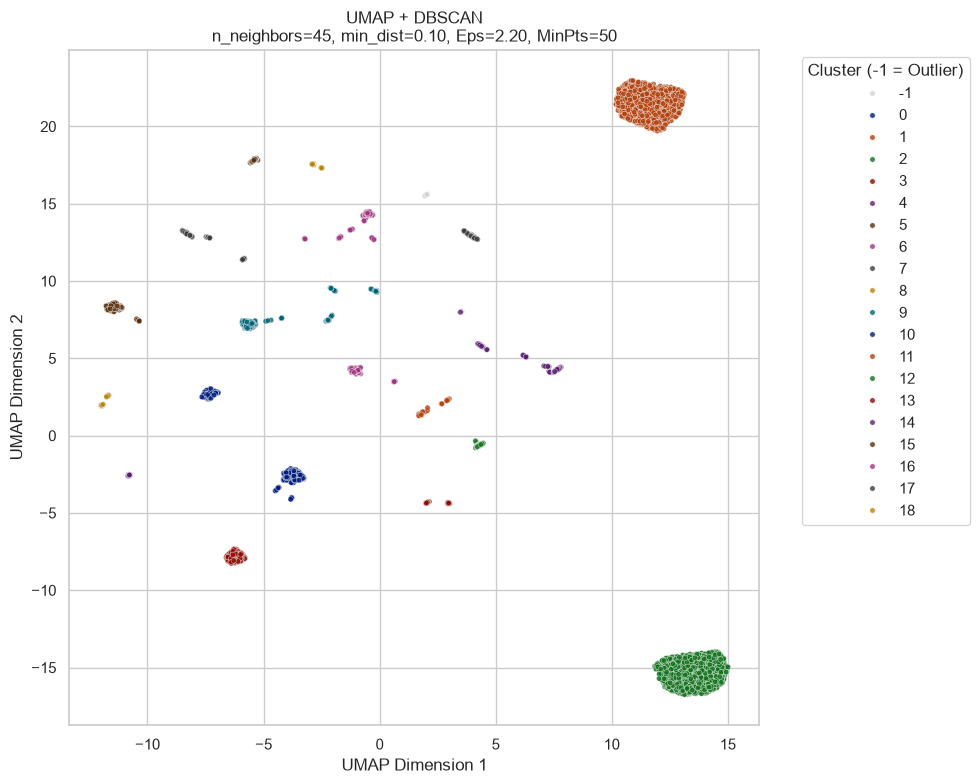

In [39]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 8))

# Identify actual clusters
unique_clusters = sorted([
    c for c in np.unique(final_labels)
    if c != -1
])

# Create palette for actual clusters
palette = {
    c: color
    for c, color in zip(
        unique_clusters,
        sns.color_palette(
            "dark",
            len(unique_clusters)
        )
    )
}

# Assign grey to DBSCAN noise
palette[-1] = "lightgrey"

# Plot UMAP embedding
sns.scatterplot(
    x=final_embedding[:, 0],
    y=final_embedding[:, 1],
    hue=final_labels,
    palette=palette,
    s=15,
    alpha=0.8
)

plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")

plt.title(
    f"UMAP + DBSCAN\n"
    f"n_neighbors={final_n_neighbors}, "
    f"min_dist={final_min_dist:.2f}, "
    f"Eps={final_eps:.2f}, "
    f"MinPts={final_min_samples}"
)

plt.legend(
    title="Cluster (-1 = Outlier)",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

## Save the Final Cluster Assignments

The patient identifier, final UMAP coordinates, and DBSCAN cluster assignment are saved for later cluster characterization and clinical analysis.

In [36]:
final_clusters_df = pd.DataFrame({
    ID_COLUMN: patient_ids.reset_index(drop=True),
    "UMAP_1": final_embedding[:, 0],
    "UMAP_2": final_embedding[:, 1],
    "Cluster": final_labels
})

final_cluster_file = (
    RESULTS_DIR / "final_umap_dbscan_clusters.csv"
)

final_clusters_df.to_csv(
    final_cluster_file,
    index=False
)

print("Final cluster assignments saved successfully.")

display(final_clusters_df.head())

Final cluster assignments saved successfully.


,patientunitstayid,UMAP_1,UMAP_2,Cluster
0,151900,-3.794609,-2.797652,0
1,165269,-4.459684,-3.532024,0
2,179269,11.033510,20.942789,1
3,172764,10.401638,20.758362,1
4,215156,12.004778,20.829334,1


## Save the Final Parameter Summary

In [37]:
final_summary = pd.DataFrame({
    "Parameter": [
        "n_neighbors",
        "min_dist",
        "Epsilon",
        "MinPts",
        "Number of Clusters",
        "Number of Outliers",
        "Outlier Percentage",
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Index"
    ],

    "Value": [
        final_n_neighbors,
        final_min_dist,
        final_eps,
        final_min_samples,
        int(final_model["Clusters"]),
        int(np.sum(final_labels == -1)),
        final_model["Outlier_Percentage"],
        final_model["Silhouette"],
        final_model["Davies_Bouldin"],
        final_model["Calinski_Harabasz"]
    ]
})

display(final_summary)

,Parameter,Value
0,n_neighbors,45.000000
1,min_dist,0.100000
2,Epsilon,2.200000
3,MinPts,50.000000
4,Number of Clusters,19.000000
5,Number of Outliers,53.000000
6,Outlier Percentage,0.674386
7,Silhouette Score,0.857395
8,Davies-Bouldin Index,0.332847
9,Calinski-Harabasz Index,105826.054617


In [38]:
summary_file = (
    RESULTS_DIR / "final_umap_dbscan_parameters.csv"
)

final_summary.to_csv(
    summary_file,
    index=False
)

print("Final parameter summary saved successfully.")
print("Saved to:", summary_file)

Final parameter summary saved successfully.
Saved to: C:\Users\samsa\Documents\ICU Clustering\results\module_2\4.umap_dbscan_tuning\final_umap_dbscan_parameters.csv
